# Clasificación de violencia en Colombia
## Pipeline CRISP-DL single-label robusto con split por evento

**Autor:** Johan Camilo Balanta Santacruz  
**Universidad San Buenaventura, Cali**

Este notebook implementa una versión **single-label robusta** del pipeline. La decisión principal es separar el objetivo principal del análisis multi-etiqueta:

- El modelo principal predice **una categoría** y **una subcategoría** por evento.
- Los eventos que tienen múltiples categorías o múltiples subcategorías se **reportan y excluyen** del entrenamiento principal, porque generan etiquetas contradictorias para un modelo `softmax`.
- El split se hace a nivel de `Id de evento`, evitando que el mismo evento aparezca en entrenamiento y prueba.

Esta versión prioriza estabilidad, interpretabilidad y defensa metodológica para tesis.

## 0. Instalación de dependencias

Ejecuta esta celda una vez por sesión en Colab.

In [16]:
!pip install -q transformers tokenizers pandas numpy scikit-learn torch matplotlib seaborn joblib

## 1. Comprensión del problema

**Objetivo:** clasificar eventos de violencia en Colombia en dos tareas single-label:

1. **Categoría:** tipo principal de violencia.
2. **Subcategoría:** subtipo específico.

**Por qué no usar los duplicados como filas independientes:** el CSV contiene varias filas por evento porque un evento puede tener varias personas afectadas o varias afectaciones. Si el mismo texto entra en train y test, hay fuga de información. Si el mismo texto aparece con etiquetas distintas dentro del entrenamiento, el modelo recibe señales contradictorias.

**Política elegida:**

- Consolidar el texto por `Id de evento`.
- Eliminar duplicados exactos evento-etiqueta.
- Mantener solo eventos con una etiqueta única para la tarea principal.
- Reportar eventos ambiguos como material para análisis cualitativo o futuro modelo multi-label.

## 2. Configuración reproducible

In [45]:
import os
import re
import json
import math
import random
import warnings
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from joblib import dump

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MODEL_CANDIDATES = {
    'beto': 'dccuchile/bert-base-spanish-wwm-cased',
    'roberta_bne': 'PlanTL-GOB-ES/roberta-base-bne',
}

CONFIG = {
    'MODEL_KEY': 'beto',
    'SEED': SEED,
    'TEST_SIZE': 0.15,
    'VAL_SIZE': 0.15,
    'MIN_SAMPLES_CATEGORY': 50,
    'MIN_SAMPLES_SUBCATEGORY': 50,
    'MIN_EVAL_EXAMPLES_PER_CLASS': 2,
    'REQUIRE_SINGLE_CATEGORY_FOR_SUBCATEGORY': True,
    'MIN_HIERARCHICAL_GROUP_SIZE': 35,
    'TARGET_MACRO_F1': 0.85,
    'MAX_LEN_CAP': 256,
    'MAX_LEN_PERCENTILE': 95,
    'BATCH_SIZE': 16,
    'EPOCHS': 6,
    'PATIENCE': 2,
    'MIN_DELTA': 1e-4,
    'DROPOUT': 0.35,
    'LABEL_SMOOTHING': 0.05,
    'LR_TRANSFORMER': 2e-5,
    'LR_HEAD': 1e-4,
    'WEIGHT_DECAY_TRANSFORMER': 1e-2,
    'WEIGHT_DECAY_HEAD': 1e-3,
    'FREEZE_EMBEDDINGS': True,
    'FREEZE_LOWER_LAYERS': 4,
    'USE_WEIGHTED_SAMPLER': True,
    'NUM_WORKERS': 0,
    'USE_HIERARCHY_FOR_SUBCATEGORY': True,
    'ARTIFACT_DIR': '/content/drive/MyDrive/violencia_classifier_artifacts',
}

MODEL_NAME = MODEL_CANDIDATES[CONFIG['MODEL_KEY']]
print(json.dumps({**CONFIG, 'MODEL_NAME': MODEL_NAME}, indent=2, ensure_ascii=False))

Device: cuda
{
  "MODEL_KEY": "beto",
  "SEED": 42,
  "TEST_SIZE": 0.15,
  "VAL_SIZE": 0.15,
  "MIN_SAMPLES_CATEGORY": 50,
  "MIN_SAMPLES_SUBCATEGORY": 50,
  "MIN_EVAL_EXAMPLES_PER_CLASS": 2,
  "REQUIRE_SINGLE_CATEGORY_FOR_SUBCATEGORY": true,
  "MIN_HIERARCHICAL_GROUP_SIZE": 35,
  "TARGET_MACRO_F1": 0.85,
  "MAX_LEN_CAP": 256,
  "MAX_LEN_PERCENTILE": 95,
  "BATCH_SIZE": 16,
  "EPOCHS": 6,
  "PATIENCE": 2,
  "MIN_DELTA": 0.0001,
  "DROPOUT": 0.35,
  "LABEL_SMOOTHING": 0.05,
  "LR_TRANSFORMER": 2e-05,
  "LR_HEAD": 0.0001,
  "WEIGHT_DECAY_TRANSFORMER": 0.01,
  "WEIGHT_DECAY_HEAD": 0.001,
  "FREEZE_EMBEDDINGS": true,
  "FREEZE_LOWER_LAYERS": 4,
  "USE_WEIGHTED_SAMPLER": true,
  "NUM_WORKERS": 0,
  "USE_HIERARCHY_FOR_SUBCATEGORY": true,
  "ARTIFACT_DIR": "/content/drive/MyDrive/violencia_classifier_artifacts",
  "MODEL_NAME": "dccuchile/bert-base-spanish-wwm-cased"
}


## 3. Carga desde Google Drive

Esta versión usa el CSV curado maestro, que ya viene consolidado por `Id de evento` y agrega banderas para indicar qué casos son aptos para categoría y subcategoría.


In [18]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_CSV_PATH = '/content/drive/MyDrive/monitor-eventos-2024-violencia_eventos_curados.csv'

df = pd.read_csv(
    DRIVE_CSV_PATH,
    sep=';',
    encoding='utf-8-sig',
    on_bad_lines='skip'
)
df.columns = [str(col).replace('﻿', '').strip() for col in df.columns]
df_raw = df.copy()

ID_COL = 'Id de evento'
TEXT_COL = 'texto_evento'
CAT_COL = 'categoria_modelo'
SUBCAT_COL = 'subcategoria_modelo'
CAT_KEEP_COL = 'es_apto_categoria'
SUBCAT_KEEP_COL = 'es_apto_subcategoria'
ORIG_CAT_COL = 'categorias_originales'
ORIG_SUBCAT_COL = 'subcategorias_originales'

required_columns = [ID_COL, TEXT_COL, CAT_COL, SUBCAT_COL, CAT_KEEP_COL, SUBCAT_KEEP_COL]
missing_required = [col for col in required_columns if col not in df_raw.columns]
if missing_required:
    raise KeyError(f'Faltan columnas obligatorias en el CSV curado: {missing_required}')

sample_idx = df_raw[TEXT_COL].first_valid_index()
print(f'Archivo: {DRIVE_CSV_PATH}')
print(f'Registros cargados: {len(df_raw):,}')
print(f'Columnas:           {list(df_raw.columns)}')
if sample_idx is not None:
    print(f'\nEjemplo de texto:\n{df_raw.loc[sample_idx, TEXT_COL]}')
    print(f'Categoría modelo:   {df_raw.loc[sample_idx, CAT_COL]}')
    print(f'Subcategoría modelo: {df_raw.loc[sample_idx, SUBCAT_COL]}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo: /content/drive/MyDrive/monitor-eventos-2024-violencia_eventos_curados.csv
Registros cargados: 2,870
Columnas:           ['Id de evento', 'texto_evento', 'n_filas_originales', 'n_categorias', 'n_subcategorias', 'categorias_originales', 'subcategorias_originales', 'categoria_original_unica', 'subcategoria_original_unica', 'categoria_modelo', 'subcategoria_modelo', 'es_apto_categoria', 'es_apto_subcategoria', 'motivo_categoria', 'motivo_subcategoria', 'support_categoria', 'support_subcategoria', 'Tipo', 'Fecha Evento', 'Fecha Final de Evento', 'Doble/Multiple Afectacion', 'Resolucion 1612', 'Resolucion 1820', 'Divipola Dpto', 'Departmento', 'Divipola Municipio', 'Municipio', 'Numero de afectados', 'Genero', 'Familia', 'Ocupacion', 'Etnia', 'Grupo poblacional', 'Edad', 'Estado', 'Condicion', 'Departamento receptor', 'Municipio receptor', 'Numero de perso

## 4. Chequeo del CSV curado

Esta fase verifica rápidamente que el CSV curado conserve una distribución razonable y que las columnas clave estén listas para modelar.

In [19]:
def clean_value(value):
    if pd.isna(value):
        return ''
    value = str(value).replace(' ', ' ').strip()
    value = re.sub(r'\s+', ' ', value)
    return value


def normalize_text(value):
    value = clean_value(value)
    value = re.sub(r'<[^>]+>', ' ', value)
    value = re.sub(r'http\S+|www\.\S+', ' URL ', value)
    value = re.sub(r'\s+', ' ', value)
    return value.strip()

required = [ID_COL, TEXT_COL, CAT_COL, SUBCAT_COL]
print('Nulos en columnas clave:')
display(df_raw[required].isna().sum().to_frame('nulos'))

print(f'Filas totales: {len(df_raw):,}')
print(f'Eventos únicos: {df_raw[ID_COL].nunique():,}')
print(f'Duplicados por Id de evento: {df_raw.duplicated(subset=[ID_COL]).sum():,}')
print(f"Casos aptos para categoría: {(df_raw[CAT_KEEP_COL].astype(str) == '1').sum():,}")
print(f"Casos aptos para subcategoría: {(df_raw[SUBCAT_KEEP_COL].astype(str) == '1').sum():,}")

print('\nTop categorías aptas:')
display(df_raw.loc[df_raw[CAT_KEEP_COL].astype(str) == '1', CAT_COL].value_counts().to_frame('eventos'))
print('\nTop subcategorías aptas:')
display(df_raw.loc[df_raw[SUBCAT_KEEP_COL].astype(str) == '1', SUBCAT_COL].value_counts().head(20).to_frame('eventos'))

top_ids = df_raw[ID_COL].value_counts().head(10).to_frame('apariciones')
top_ids.index.name = 'Id de evento'
print('\nEventos con más filas:')
display(top_ids)


Nulos en columnas clave:


,nulos
Id de evento,0
texto_evento,0
categoria_modelo,0
subcategoria_modelo,0


Filas totales: 2,870
Eventos únicos: 2,870
Duplicados por Id de evento: 0
Casos aptos para categoría: 2,449
Casos aptos para subcategoría: 1,806

Top categorías aptas:


,eventos
categoria_modelo,
Ataques contra la población civil,1539
Acciones armadas,443
Uso de artefactos explosivos,219
Restricción al acceso humanitario,196
Desplazamiento forzado,52



Top subcategorías aptas:


,eventos
subcategoria_modelo,
Homicidio intencional en persona protegida,790
Secuestro,174
Amenazas (individuales/colectivas),165
Combates,152
Atentado,107
Trampas explosivas- TE,102
Hostigamiento,99
Mina antipersonal - MAP,78
Enfrentamiento entre actores no estatales,74



Eventos con más filas:


,apariciones
Id de evento,
6973,1
3212,1
3213,1
3223,1
3224,1
3228,1
3266,1
3267,1
3274,1


## 5. Preparación de texto

El CSV curado ya viene consolidado por evento, así que aquí sólo normalizamos el texto y dejamos listas las columnas útiles.

In [20]:
events_df = df_raw[[ID_COL, TEXT_COL, CAT_COL, SUBCAT_COL, CAT_KEEP_COL, SUBCAT_KEEP_COL]].copy()
events_df[ID_COL] = events_df[ID_COL].apply(clean_value)
events_df[TEXT_COL] = events_df[TEXT_COL].apply(normalize_text)
events_df[CAT_COL] = events_df[CAT_COL].apply(clean_value)
events_df[SUBCAT_COL] = events_df[SUBCAT_COL].apply(clean_value)
events_df['primary_category'] = events_df[CAT_COL]

print(f'Eventos curados listos para modelar: {len(events_df):,}')
display(events_df.head(5))


Eventos curados listos para modelar: 2,870


,Id de evento,texto_evento,categoria_modelo,subcategoria_modelo,es_apto_categoria,es_apto_subcategoria,primary_category
0,3212,Un soldado muerto y 12 heridos en ataque del C...,Acciones armadas,NO_USAR,1,0,Acciones armadas
1,3213,Asesinan a migrante venezolana en Medellín || ...,Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,Ataques contra la población civil
2,3223,"Asesinan a un hombre en Copacabana, Antioquia ...",Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,Ataques contra la población civil
3,3224,"Asesinan a un hombre en Girardota, Antioquia |...",Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,Ataques contra la población civil
4,3228,Joven asesinado en la comuna 13 de Medellín ||...,Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,Ataques contra la población civil


## 6. Construcción de datasets single-label de alto rendimiento

Para perseguir `macro-F1 >= 0.85`, el experimento principal se concentra en clases con soporte suficiente. Las clases raras no se mezclan artificialmente: quedan reportadas como fuera de cobertura para que el resultado sea honesto y comparable.


In [21]:
def min_samples_for_stratified_split():
    eval_fraction = min(CONFIG['VAL_SIZE'], CONFIG['TEST_SIZE'])
    min_eval = CONFIG.get('MIN_EVAL_EXAMPLES_PER_CLASS', 1)
    return max(4, math.ceil(min_eval / eval_fraction))


def make_single_label_dataset(events, label_col, label_name, min_samples, keep_col):
    clean_df = events[events[keep_col].astype(str) == '1'].copy()
    excluded_df = events[events[keep_col].astype(str) != '1'].copy()
    clean_df['label'] = clean_df[label_col].apply(clean_value)

    counts = clean_df['label'].value_counts()
    effective_min_samples = max(min_samples, min_samples_for_stratified_split())
    valid_labels = counts[counts >= effective_min_samples].index.tolist()
    removed_labels = counts[counts < effective_min_samples]
    model_df = clean_df[clean_df['label'].isin(valid_labels)].reset_index(drop=True)
    coverage = len(model_df) / max(1, len(clean_df))

    if model_df['label'].nunique() < 2:
        raise ValueError(
            f'El dataset de {label_name} quedó con menos de 2 clases. '
            f'Baja el umbral mínimo o revisa las etiquetas curadas.'
        )

    print(f'\n=== Dataset {label_name} ===')
    print(f'Casos aptos antes del umbral: {len(clean_df):,}')
    print(f'Casos excluidos por la curación: {len(excluded_df):,}')
    print(f'Umbral efectivo por clase: >= {effective_min_samples} eventos')
    print(f'Casos conservados: {len(model_df):,} ({coverage:.1%} de cobertura single-label)')
    print(f'Clases conservadas: {len(valid_labels)} de {len(counts)}')
    display(counts.to_frame('eventos'))
    if len(removed_labels):
        print('Clases fuera de cobertura por pocos ejemplos:')
        display(removed_labels.to_frame('eventos'))

    return model_df, excluded_df, counts, removed_labels, coverage

cat_df, cat_ambiguous, cat_counts, cat_removed, cat_coverage = make_single_label_dataset(
    events_df, CAT_COL, 'categoría', CONFIG['MIN_SAMPLES_CATEGORY'], CAT_KEEP_COL
)
sub_df, sub_ambiguous, sub_counts, sub_removed, sub_coverage = make_single_label_dataset(
    events_df, SUBCAT_COL, 'subcategoría', CONFIG['MIN_SAMPLES_SUBCATEGORY'], SUBCAT_KEEP_COL
)

coverage_summary = pd.DataFrame([
    {'dataset': 'categoría', 'eventos_entrenables': len(cat_df), 'clases': cat_df['label'].nunique(), 'cobertura_single_label': cat_coverage},
    {'dataset': 'subcategoría', 'eventos_entrenables': len(sub_df), 'clases': sub_df['label'].nunique(), 'cobertura_single_label': sub_coverage},
])
display(coverage_summary)

print('\nEjemplos excluidos de categoría:')
display(cat_ambiguous[[ID_COL, CAT_COL, SUBCAT_COL, TEXT_COL]].head(5))
print('\nEjemplos excluidos de subcategoría:')
display(sub_ambiguous[[ID_COL, CAT_COL, SUBCAT_COL, TEXT_COL]].head(5))



=== Dataset categoría ===
Casos aptos antes del umbral: 2,449
Casos excluidos por la curación: 421
Umbral efectivo por clase: >= 50 eventos
Casos conservados: 2,449 (100.0% de cobertura single-label)
Clases conservadas: 5 de 5


,eventos
label,
Ataques contra la población civil,1539
Acciones armadas,443
Uso de artefactos explosivos,219
Restricción al acceso humanitario,196
Desplazamiento forzado,52



=== Dataset subcategoría ===
Casos aptos antes del umbral: 1,806
Casos excluidos por la curación: 1,064
Umbral efectivo por clase: >= 50 eventos
Casos conservados: 1,806 (100.0% de cobertura single-label)
Clases conservadas: 10 de 10


,eventos
label,
Homicidio intencional en persona protegida,790
Secuestro,174
Amenazas (individuales/colectivas),165
Combates,152
Atentado,107
Trampas explosivas- TE,102
Hostigamiento,99
Mina antipersonal - MAP,78
Enfrentamiento entre actores no estatales,74


,dataset,eventos_entrenables,clases,cobertura_single_label
0,categoría,2449,5,1.0
1,subcategoría,1806,10,1.0



Ejemplos excluidos de categoría:


,Id de evento,categoria_modelo,subcategoria_modelo,texto_evento
11,3329,NO_USAR,NO_USAR,"Asesinan a lider social en Amagá, Antioquia ||..."
43,3401,NO_USAR,NO_USAR,Doble homicidio en Cauca: una de las víctimas ...
85,3456,NO_USAR,NO_USAR,Desplazamiento masivos de las veredas Samarita...
88,3459,NO_USAR,NO_USAR,Desplazamiento masivo intraurbano e interdepar...
90,3462,NO_USAR,NO_USAR,Queman ambulancia en vía de Huila: conductor y...



Ejemplos excluidos de subcategoría:


,Id de evento,categoria_modelo,subcategoria_modelo,texto_evento
0,3212,Acciones armadas,NO_USAR,Un soldado muerto y 12 heridos en ataque del C...
11,3329,NO_USAR,NO_USAR,"Asesinan a lider social en Amagá, Antioquia ||..."
12,3352,Ataques contra la población civil,NO_USAR,"Asesinan a lider social en Andes, Antioquia ||..."
13,3353,Acciones armadas,NO_USAR,Un grupo fuertemente armado hace presencia en ...
25,3367,Ataques contra la población civil,NO_USAR,De varios tiros asesinan a joven en zona rural...


## 7. Split estratificado por evento

Como cada fila ya representa un evento único, el split estratificado conserva la distribución de clases y no permite solapamiento de eventos entre train, validación y test.

In [22]:
def stratified_event_split(df, label_col='label', id_col=ID_COL, seed=SEED):
    counts = df[label_col].value_counts()
    if counts.min() < min_samples_for_stratified_split():
        raise ValueError(
            'Hay clases con muy pocos ejemplos para un split estratificado estable. '
            'Revisa el umbral de make_single_label_dataset.'
        )

    train_df, temp_df = train_test_split(
        df,
        test_size=CONFIG['VAL_SIZE'] + CONFIG['TEST_SIZE'],
        random_state=seed,
        stratify=df[label_col],
    )
    relative_test = CONFIG['TEST_SIZE'] / (CONFIG['VAL_SIZE'] + CONFIG['TEST_SIZE'])
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test,
        random_state=seed,
        stratify=temp_df[label_col],
    )

    overlap_tv = set(train_df[id_col]) & set(val_df[id_col])
    overlap_tt = set(train_df[id_col]) & set(test_df[id_col])
    overlap_vt = set(val_df[id_col]) & set(test_df[id_col])
    assert not overlap_tv and not overlap_tt and not overlap_vt, 'Hay fuga de eventos entre splits.'
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

cat_train_df, cat_val_df, cat_test_df = stratified_event_split(cat_df)
sub_train_df, sub_val_df, sub_test_df = stratified_event_split(sub_df)


def show_split_distribution(train_df, val_df, test_df, title):
    table = pd.DataFrame({
        'train': train_df['label'].value_counts(),
        'val': val_df['label'].value_counts(),
        'test': test_df['label'].value_counts(),
    }).fillna(0).astype(int)
    table['total'] = table.sum(axis=1)
    print(f'\nDistribución por split - {title}')
    display(table.sort_values('total', ascending=False))
    missing = table[(table['train'] == 0) | (table['val'] == 0) | (table['test'] == 0)]
    if len(missing):
        raise ValueError('Hay clases ausentes en algún split; aumenta el umbral mínimo o ajusta los tamaños de split.')

show_split_distribution(cat_train_df, cat_val_df, cat_test_df, 'categoría')
show_split_distribution(sub_train_df, sub_val_df, sub_test_df, 'subcategoría')



Distribución por split - categoría


,train,val,test,total
label,,,,
Ataques contra la población civil,1077,231,231,1539
Acciones armadas,310,66,67,443
Uso de artefactos explosivos,153,33,33,219
Restricción al acceso humanitario,137,29,30,196
Desplazamiento forzado,37,8,7,52



Distribución por split - subcategoría


,train,val,test,total
label,,,,
Homicidio intencional en persona protegida,553,118,119,790
Secuestro,122,26,26,174
Amenazas (individuales/colectivas),115,25,25,165
Combates,106,23,23,152
Atentado,75,16,16,107
Trampas explosivas- TE,71,16,15,102
Hostigamiento,69,15,15,99
Mina antipersonal - MAP,55,12,11,78
Enfrentamiento entre actores no estatales,52,11,11,74


## 8. Codificación de etiquetas

In [23]:
def encode_splits(train_df, val_df, test_df):
    le = LabelEncoder()
    y_train = le.fit_transform(train_df['label'])
    y_val = le.transform(val_df['label'])
    y_test = le.transform(test_df['label'])
    return {
        'le': le,
        'train_df': train_df.reset_index(drop=True),
        'val_df': val_df.reset_index(drop=True),
        'test_df': test_df.reset_index(drop=True),
        'X_train': train_df['texto_evento'].values,
        'X_val': val_df['texto_evento'].values,
        'X_test': test_df['texto_evento'].values,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }

cat_data = encode_splits(cat_train_df, cat_val_df, cat_test_df)
sub_data = encode_splits(sub_train_df, sub_val_df, sub_test_df)
print('Clases categoría:', list(cat_data['le'].classes_))
print('Número de subcategorías:', len(sub_data['le'].classes_))


Clases categoría: ['Acciones armadas', 'Ataques contra la población civil', 'Desplazamiento forzado', 'Restricción al acceso humanitario', 'Uso de artefactos explosivos']
Número de subcategorías: 10


## 9. Baselines fuertes: TF-IDF global y jerárquico

El baseline global combina n-gramas de palabras y caracteres. Para subcategoría añadimos un baseline jerárquico: primero separa por categoría y luego clasifica sólo entre subcategorías plausibles de esa familia.


In [24]:
def evaluar_predicciones(y_true, y_pred, le, title):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    print(f'\n=== {title} ===')
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}')
    print(classification_report(y_true, y_pred, labels=np.arange(len(le.classes_)), target_names=le.classes_, zero_division=0))
    return metrics


def make_text_classifier():
    return Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                lowercase=True,
                strip_accents='unicode',
                analyzer='word',
                ngram_range=(1, 2),
                min_df=1,
                max_features=60000,
                sublinear_tf=True,
            )),
            ('char', TfidfVectorizer(
                lowercase=True,
                strip_accents='unicode',
                analyzer='char_wb',
                ngram_range=(3, 5),
                min_df=2,
                max_features=40000,
                sublinear_tf=True,
            )),
        ])),
        ('clf', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            solver='liblinear',
            random_state=CONFIG['SEED'],
        )),
    ])


def train_baseline(data, title):
    model = make_text_classifier()
    model.fit(data['X_train'], data['y_train'])
    pred_val = model.predict(data['X_val'])
    pred_test = model.predict(data['X_test'])
    val_metrics = evaluar_predicciones(data['y_val'], pred_val, data['le'], f'Baseline global {title} - validación')
    test_metrics = evaluar_predicciones(data['y_test'], pred_test, data['le'], f'Baseline global {title} - test')
    return model, val_metrics, test_metrics, pred_test


def train_hierarchical_subcategory_baseline(data):
    le = data['le']
    train_df = data['train_df'].copy()
    val_df = data['val_df'].copy()
    test_df = data['test_df'].copy()
    global_model = make_text_classifier()
    global_model.fit(data['X_train'], data['y_train'])

    routers = {}
    for category, group in train_df.groupby('primary_category'):
        y_group = le.transform(group['label'])
        if group['label'].nunique() >= 2 and len(group) >= CONFIG['MIN_HIERARCHICAL_GROUP_SIZE']:
            model = make_text_classifier()
            model.fit(group['texto_evento'].values, y_group)
            routers[category] = {'type': 'model', 'model': model, 'n': len(group), 'classes': sorted(group['label'].unique())}
        else:
            majority_label = group['label'].value_counts().idxmax()
            routers[category] = {'type': 'majority', 'label': int(le.transform([majority_label])[0]), 'n': len(group), 'classes': sorted(group['label'].unique())}

    def predict(df):
        preds = []
        for _, row in df.iterrows():
            router = routers.get(row['primary_category'])
            if router is None:
                pred = int(global_model.predict([row['texto_evento']])[0])
            elif router['type'] == 'majority':
                pred = router['label']
            else:
                pred = int(router['model'].predict([row['texto_evento']])[0])
            preds.append(pred)
        return np.array(preds)

    print('\nRuteadores jerárquicos por categoría:')
    display(pd.DataFrame([
        {'categoria': cat, 'tipo': router['type'], 'n_train': router['n'], 'subcategorias': len(router['classes'])}
        for cat, router in routers.items()
    ]).sort_values(['tipo', 'n_train'], ascending=[True, False]))

    pred_val = predict(val_df)
    pred_test = predict(test_df)
    val_metrics = evaluar_predicciones(data['y_val'], pred_val, le, 'Baseline jerárquico subcategoría - validación')
    test_metrics = evaluar_predicciones(data['y_test'], pred_test, le, 'Baseline jerárquico subcategoría - test')
    return routers, global_model, val_metrics, test_metrics, pred_test

baseline_cat, baseline_cat_val, baseline_cat_test, baseline_cat_pred = train_baseline(cat_data, 'categoría')
baseline_sub, baseline_sub_val, baseline_sub_test, baseline_sub_pred = train_baseline(sub_data, 'subcategoría')
hier_sub_routers, hier_sub_global, hier_sub_val, hier_sub_test, hier_sub_pred = train_hierarchical_subcategory_baseline(sub_data)



=== Baseline global categoría - validación ===
accuracy: 0.9074
f1_macro: 0.8823
f1_weighted: 0.9067
                                   precision    recall  f1-score   support

                 Acciones armadas       0.82      0.83      0.83        66
Ataques contra la población civil       0.93      0.95      0.94       231
           Desplazamiento forzado       1.00      0.88      0.93         8
Restricción al acceso humanitario       0.92      0.76      0.83        29
     Uso de artefactos explosivos       0.88      0.88      0.88        33

                         accuracy                           0.91       367
                        macro avg       0.91      0.86      0.88       367
                     weighted avg       0.91      0.91      0.91       367


=== Baseline global categoría - test ===
accuracy: 0.9185
f1_macro: 0.8959
f1_weighted: 0.9181
                                   precision    recall  f1-score   support

                 Acciones armadas       0.95    

,categoria,tipo,n_train,subcategorias
1,Ataques contra la población civil,model,911,5
0,Acciones armadas,model,227,3
2,Uso de artefactos explosivos,model,126,2



=== Baseline jerárquico subcategoría - validación ===
accuracy: 0.8782
f1_macro: 0.8333
f1_weighted: 0.8733
                                                     precision    recall  f1-score   support

                 Amenazas (individuales/colectivas)       0.88      0.84      0.86        25
                                           Atentado       0.55      0.38      0.44        16
                                           Combates       0.88      0.91      0.89        23
          Enfrentamiento entre actores no estatales       1.00      0.73      0.84        11
         Homicidio intencional en persona protegida       0.91      0.95      0.93       118
                                      Hostigamiento       0.88      1.00      0.94        15
                            Mina antipersonal - MAP       0.85      0.92      0.88        12
Reclutamiento, vinculación y utilización de menores       0.78      0.78      0.78         9
                                          Secuestro  

## 10. Tokenizador y longitud máxima

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (999 > 512). Running this sequence through the model will result in indexing errors


count    2978.000000
mean      120.116857
std        72.728320
min        23.000000
25%        77.000000
50%       103.000000
75%       145.000000
max       999.000000
dtype: float64
MAX_LEN seleccionado: 240


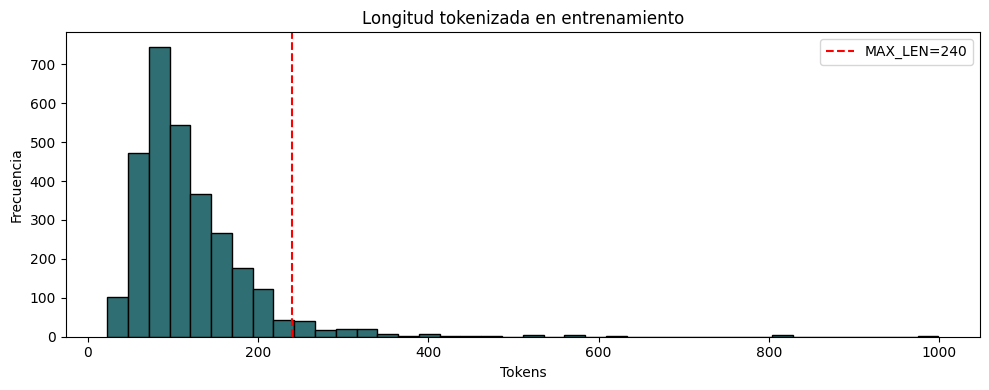

In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

all_train_texts = np.concatenate([cat_data['X_train'], sub_data['X_train']])
token_lengths = pd.Series([
    len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
    for text in all_train_texts
])
max_len_dynamic = int(np.percentile(token_lengths, CONFIG['MAX_LEN_PERCENTILE']))
max_len_dynamic = int(math.ceil(max(max_len_dynamic, 32) / 8) * 8)
MAX_LEN = min(CONFIG['MAX_LEN_CAP'], max_len_dynamic)

print(token_lengths.describe())
print(f'MAX_LEN seleccionado: {MAX_LEN}')

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=40, color='#2F6F73', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Longitud tokenizada en entrenamiento')
plt.xlabel('Tokens')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Dataset y DataLoaders

In [26]:
class ViolenciaDataset(Dataset):
    def __init__(self, textos, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(textos),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': self.labels[idx],
        }


def make_weighted_sampler(labels):
    counts = Counter(labels)
    weights = np.array([1.0 / counts[int(label)] for label in labels], dtype=np.float64)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


def make_loaders(data):
    train_ds = ViolenciaDataset(data['X_train'], data['y_train'], tokenizer, MAX_LEN)
    val_ds = ViolenciaDataset(data['X_val'], data['y_val'], tokenizer, MAX_LEN)
    test_ds = ViolenciaDataset(data['X_test'], data['y_test'], tokenizer, MAX_LEN)
    sampler = make_weighted_sampler(data['y_train']) if CONFIG['USE_WEIGHTED_SAMPLER'] else None
    return (
        DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=sampler is None, sampler=sampler,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
        DataLoader(val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
        DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
    )

cat_train_loader, cat_val_loader, cat_test_loader = make_loaders(cat_data)
sub_train_loader, sub_val_loader, sub_test_loader = make_loaders(sub_data)
print(f'Categoría batches train/val/test: {len(cat_train_loader)}, {len(cat_val_loader)}, {len(cat_test_loader)}')
print(f'Subcategoría batches train/val/test: {len(sub_train_loader)}, {len(sub_val_loader)}, {len(sub_test_loader)}')

Categoría batches train/val/test: 108, 23, 23
Subcategoría batches train/val/test: 79, 17, 17


## 12. Modelo Transformer single-label

In [27]:
class TransformerClasificador(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.30, extra_features=0):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden = self.transformer.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden + extra_features, 256)
        self.drop2 = nn.Dropout(dropout)
        self.out = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask, extra=None):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        if extra is not None:
            cls = torch.cat([cls, extra], dim=1)
        x = F.gelu(self.fc1(cls))
        x = self.drop2(x)
        return self.out(x)


def freeze_lower_layers(model, freeze_embeddings=True, freeze_layers=0):
    frozen = 0
    base = model.transformer
    if freeze_embeddings and hasattr(base, 'embeddings'):
        for p in base.embeddings.parameters():
            p.requires_grad = False
            frozen += p.numel()
    layers = getattr(getattr(base, 'encoder', None), 'layer', None)
    if layers is not None:
        for layer in layers[:freeze_layers]:
            for p in layer.parameters():
                p.requires_grad = False
                frozen += p.numel()
    return frozen


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model_cat = TransformerClasificador(MODEL_NAME, len(cat_data['le'].classes_), CONFIG['DROPOUT']).to(DEVICE)
extra_sub = len(cat_data['le'].classes_) if CONFIG['USE_HIERARCHY_FOR_SUBCATEGORY'] else 0
model_sub = TransformerClasificador(MODEL_NAME, len(sub_data['le'].classes_), CONFIG['DROPOUT'], extra_features=extra_sub).to(DEVICE)

frozen_cat = freeze_lower_layers(model_cat, CONFIG['FREEZE_EMBEDDINGS'], CONFIG['FREEZE_LOWER_LAYERS'])
frozen_sub = freeze_lower_layers(model_sub, CONFIG['FREEZE_EMBEDDINGS'], CONFIG['FREEZE_LOWER_LAYERS'])
for title, model, frozen in [('Categoría', model_cat, frozen_cat), ('Subcategoría', model_sub, frozen_sub)]:
    total, trainable = count_params(model)
    print(f'{title}: total={total:,} | entrenables={trainable:,} | congelados={frozen:,}')

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Categoría: total=110,049,029 | entrenables=57,491,717 | congelados=52,557,312
Subcategoría: total=110,051,594 | entrenables=57,494,282 | congelados=52,557,312


## 13. Pérdida, optimizador y entrenamiento

In [28]:
def make_criterion(labels, num_classes):
    weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=labels)
    weights = np.sqrt(weights)
    weights = weights / weights.mean()
    return nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE),
        label_smoothing=CONFIG['LABEL_SMOOTHING'],
    )

criterion_cat = make_criterion(cat_data['y_train'], len(cat_data['le'].classes_))
criterion_sub = make_criterion(sub_data['y_train'], len(sub_data['le'].classes_))


def crear_optimizer_scheduler(model, train_loader):
    transformer_params = [p for p in model.transformer.parameters() if p.requires_grad]
    head_params = [p for name, p in model.named_parameters() if p.requires_grad and not name.startswith('transformer.')]
    optimizer = torch.optim.AdamW([
        {'params': transformer_params, 'lr': CONFIG['LR_TRANSFORMER'], 'weight_decay': CONFIG['WEIGHT_DECAY_TRANSFORMER']},
        {'params': head_params, 'lr': CONFIG['LR_HEAD'], 'weight_decay': CONFIG['WEIGHT_DECAY_HEAD']},
    ])
    total_steps = max(1, CONFIG['EPOCHS'] * len(train_loader))
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(total_steps * 0.08)),
        num_training_steps=total_steps,
    )
    return optimizer, scheduler


def get_category_extra(model_cat_ref, input_ids, attention_mask):
    if model_cat_ref is None:
        return None
    model_cat_ref.eval()
    with torch.no_grad():
        return F.softmax(model_cat_ref(input_ids, attention_mask), dim=1)


def train_epoch(model, loader, optimizer, scheduler, criterion, model_cat_ref=None):
    model.train()
    total_loss = 0.0
    preds, labels_all = [], []
    use_amp = DEVICE.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            extra = get_category_extra(model_cat_ref, input_ids, attention_mask)
            logits = model(input_ids, attention_mask, extra=extra)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * len(labels)
        preds.extend(logits.argmax(1).detach().cpu().numpy())
        labels_all.extend(labels.detach().cpu().numpy())

    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(labels_all, preds),
        'f1_macro': f1_score(labels_all, preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(labels_all, preds, average='weighted', zero_division=0),
    }


def evaluate_loader(model, loader, criterion, model_cat_ref=None):
    model.eval()
    total_loss = 0.0
    preds, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            extra = get_category_extra(model_cat_ref, input_ids, attention_mask)
            logits = model(input_ids, attention_mask, extra=extra)
            loss = criterion(logits, labels)
            probs = F.softmax(logits, dim=1)
            total_loss += loss.item() * len(labels)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(labels_all, preds),
        'f1_macro': f1_score(labels_all, preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(labels_all, preds, average='weighted', zero_division=0),
        'preds': np.array(preds),
        'labels': np.array(labels_all),
        'probs': np.array(probs_all),
    }


def entrenar_modelo(model, train_loader, val_loader, criterion, title, model_cat_ref=None):
    optimizer, scheduler = crear_optimizer_scheduler(model, train_loader)
    best_f1 = -1.0
    best_state = None
    patience_count = 0
    history = []

    print(f'\n=== Entrenando {title} ===')
    print(f'{"época":>5} | {"tr_loss":>8} | {"tr_f1m":>7} | {"val_loss":>8} | {"val_f1m":>7} | {"val_f1w":>7}')
    print('-' * 68)

    for epoch in range(1, CONFIG['EPOCHS'] + 1):
        train_metrics = train_epoch(model, train_loader, optimizer, scheduler, criterion, model_cat_ref)
        val_metrics = evaluate_loader(model, val_loader, criterion, model_cat_ref)
        row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()},
               **{f'val_{k}': v for k, v in val_metrics.items() if k not in ['preds', 'labels', 'probs']}}
        history.append(row)
        print(f'{epoch:5d} | {train_metrics["loss"]:8.4f} | {train_metrics["f1_macro"]:7.4f} | '
              f'{val_metrics["loss"]:8.4f} | {val_metrics["f1_macro"]:7.4f} | {val_metrics["f1_weighted"]:7.4f}')

        if val_metrics['f1_macro'] > best_f1 + CONFIG['MIN_DELTA']:
            best_f1 = val_metrics['f1_macro']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= CONFIG['PATIENCE']:
                print(f'Early stopping en época {epoch}.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'Mejor F1 Macro validación {title}: {best_f1:.4f}')
    return pd.DataFrame(history)

## 14. Entrenar modelo de categoría

In [29]:
history_cat = entrenar_modelo(
    model_cat,
    cat_train_loader,
    cat_val_loader,
    criterion_cat,
    title='categoría',
)


=== Entrenando categoría ===
época |  tr_loss |  tr_f1m | val_loss | val_f1m | val_f1w
--------------------------------------------------------------------
    1 |   1.0014 |  0.5216 |   0.7417 |  0.8087 |  0.8097
    2 |   0.3009 |  0.9448 |   0.6878 |  0.8460 |  0.8790
    3 |   0.2868 |  0.9636 |   0.5834 |  0.9015 |  0.9149
    4 |   0.2514 |  0.9780 |   0.6024 |  0.9010 |  0.9129
    5 |   0.2459 |  0.9868 |   0.5660 |  0.9117 |  0.9301
    6 |   0.2374 |  0.9896 |   0.5825 |  0.9051 |  0.9225
Mejor F1 Macro validación categoría: 0.9117


## 15. Entrenar modelo de subcategoría

In [30]:
sub_model_cat_ref = model_cat if CONFIG['USE_HIERARCHY_FOR_SUBCATEGORY'] else None
if sub_model_cat_ref is not None:
    for p in model_cat.parameters():
        p.requires_grad_(False)
    model_cat.eval()

history_sub = entrenar_modelo(
    model_sub,
    sub_train_loader,
    sub_val_loader,
    criterion_sub,
    title='subcategoría',
    model_cat_ref=sub_model_cat_ref,
)


=== Entrenando subcategoría ===
época |  tr_loss |  tr_f1m | val_loss | val_f1m | val_f1w
--------------------------------------------------------------------
    1 |   2.0193 |  0.2464 |   1.5970 |  0.5429 |  0.3351
    2 |   0.8298 |  0.7939 |   0.8706 |  0.7890 |  0.7846
    3 |   0.5120 |  0.9168 |   0.7429 |  0.8309 |  0.8817
    4 |   0.3964 |  0.9593 |   0.7351 |  0.8271 |  0.8772
    5 |   0.3563 |  0.9746 |   0.7748 |  0.8383 |  0.8916
    6 |   0.3311 |  0.9914 |   0.7738 |  0.8512 |  0.8999
Mejor F1 Macro validación subcategoría: 0.8512


## 16. Curvas de aprendizaje

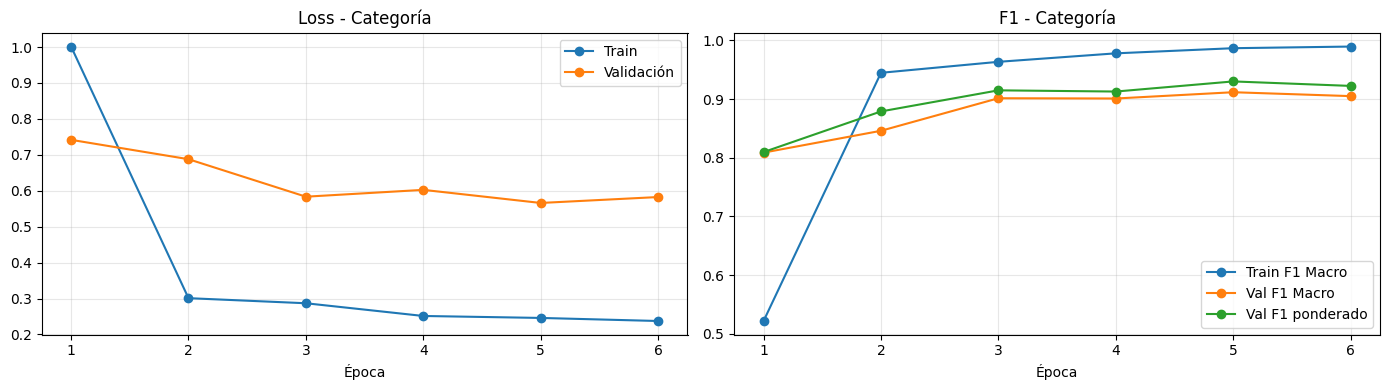

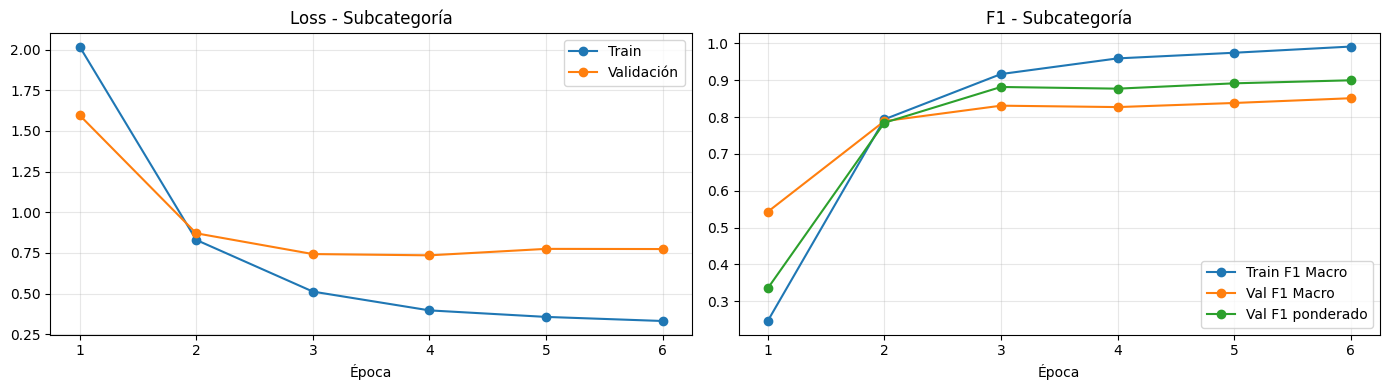

In [31]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train')
    axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='Validación')
    axes[0].set_title(f'Loss - {title}')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['epoch'], history['train_f1_macro'], marker='o', label='Train F1 Macro')
    axes[1].plot(history['epoch'], history['val_f1_macro'], marker='o', label='Val F1 Macro')
    axes[1].plot(history['epoch'], history['val_f1_weighted'], marker='o', label='Val F1 ponderado')
    axes[1].set_title(f'F1 - {title}')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_cat, 'Categoría')
plot_history(history_sub, 'Subcategoría')

## 17. Evaluación final en test

In [32]:
result_cat = evaluate_loader(model_cat, cat_test_loader, criterion_cat)
result_sub = evaluate_loader(model_sub, sub_test_loader, criterion_sub, model_cat_ref=sub_model_cat_ref)

print('=== RESULTADOS TEST - TRANSFORMER CATEGORÍA ===')
print({k: round(v, 4) for k, v in result_cat.items() if k in ['loss', 'accuracy', 'f1_macro', 'f1_weighted']})
print(classification_report(result_cat['labels'], result_cat['preds'], labels=np.arange(len(cat_data['le'].classes_)), target_names=cat_data['le'].classes_, zero_division=0))

print('=== RESULTADOS TEST - TRANSFORMER SUBCATEGORÍA ===')
print({k: round(v, 4) for k, v in result_sub.items() if k in ['loss', 'accuracy', 'f1_macro', 'f1_weighted']})
print(classification_report(result_sub['labels'], result_sub['preds'], labels=np.arange(len(sub_data['le'].classes_)), target_names=sub_data['le'].classes_, zero_division=0))

comparacion = pd.DataFrame([
    {'modelo': 'Baseline global categoría', **baseline_cat_test},
    {'modelo': 'Transformer categoría', **{k: result_cat[k] for k in ['accuracy', 'f1_macro', 'f1_weighted']}},
    {'modelo': 'Baseline global subcategoría', **baseline_sub_test},
    {'modelo': 'Baseline jerárquico subcategoría', **hier_sub_test},
    {'modelo': 'Transformer subcategoría', **{k: result_sub[k] for k in ['accuracy', 'f1_macro', 'f1_weighted']}},
])
display(comparacion)

objetivo = CONFIG['TARGET_MACRO_F1']
comparacion['cumple_objetivo_macro'] = comparacion['f1_macro'] >= objetivo
print(f'Objetivo macro-F1: >= {objetivo:.2f}')
display(comparacion.sort_values('f1_macro', ascending=False))


=== RESULTADOS TEST - TRANSFORMER CATEGORÍA ===
{'loss': 0.656, 'accuracy': 0.9293, 'f1_macro': 0.8979, 'f1_weighted': 0.9297}
                                   precision    recall  f1-score   support

                 Acciones armadas       0.93      0.82      0.87        67
Ataques contra la población civil       0.96      0.95      0.96       231
           Desplazamiento forzado       0.78      1.00      0.88         7
Restricción al acceso humanitario       0.90      0.93      0.92        30
     Uso de artefactos explosivos       0.78      0.97      0.86        33

                         accuracy                           0.93       368
                        macro avg       0.87      0.94      0.90       368
                     weighted avg       0.93      0.93      0.93       368

=== RESULTADOS TEST - TRANSFORMER SUBCATEGORÍA ===
{'loss': 0.6898, 'accuracy': 0.9262, 'f1_macro': 0.8871, 'f1_weighted': 0.9273}
                                                     precision  

,modelo,accuracy,f1_macro,f1_weighted
0,Baseline global categoría,0.918478,0.895913,0.918137
1,Transformer categoría,0.929348,0.897904,0.929719
2,Baseline global subcategoría,0.900369,0.850542,0.896140
3,Baseline jerárquico subcategoría,0.896679,0.847480,0.893215
4,Transformer subcategoría,0.926199,0.887131,0.927327


Objetivo macro-F1: >= 0.85


,modelo,accuracy,f1_macro,f1_weighted,cumple_objetivo_macro
1,Transformer categoría,0.929348,0.897904,0.929719,True
0,Baseline global categoría,0.918478,0.895913,0.918137,True
4,Transformer subcategoría,0.926199,0.887131,0.927327,True
2,Baseline global subcategoría,0.900369,0.850542,0.896140,True
3,Baseline jerárquico subcategoría,0.896679,0.847480,0.893215,False


## 18. Matrices de confusión

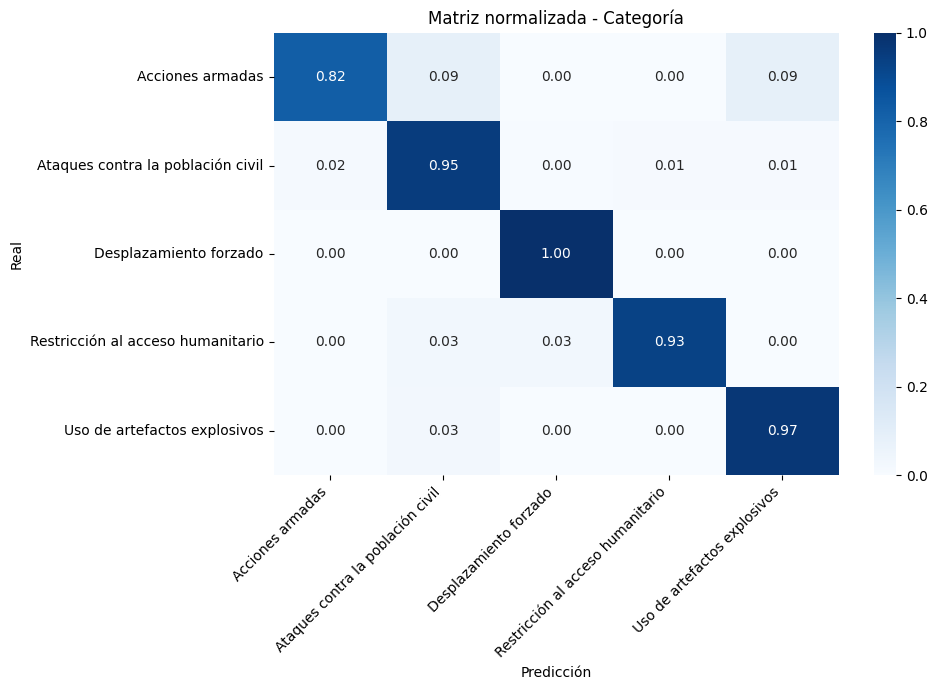

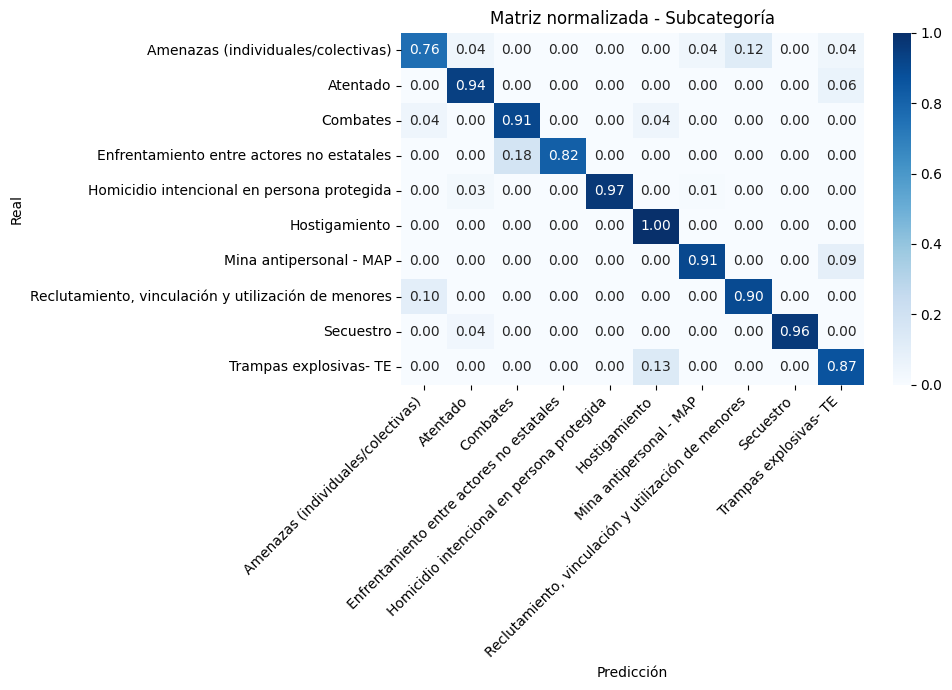

In [33]:
def plot_confusion(y_true, y_pred, labels, title, max_annot=35):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True), out=np.zeros_like(cm, dtype=float), where=cm.sum(axis=1, keepdims=True) != 0)
    figsize = (min(24, max(10, len(labels) * 0.55)), min(20, max(7, len(labels) * 0.45)))
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm_norm,
        annot=len(labels) <= max_annot,
        fmt='.2f',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(result_cat['labels'], result_cat['preds'], cat_data['le'].classes_, 'Matriz normalizada - Categoría')
plot_confusion(result_sub['labels'], result_sub['preds'], sub_data['le'].classes_, 'Matriz normalizada - Subcategoría')

## 19. Análisis de errores

In [34]:
def error_examples(data, result, le, n=20):
    rows = []
    for text, real, pred, probs in zip(data['X_test'], result['labels'], result['preds'], result['probs']):
        if real == pred:
            continue
        rows.append({
            'texto': text[:500],
            'real': le.classes_[real],
            'predicción': le.classes_[pred],
            'confianza_predicción': float(probs[pred]),
            'confianza_real': float(probs[real]),
        })
    return pd.DataFrame(rows).sort_values('confianza_predicción', ascending=False).head(n)

print('Errores de mayor confianza - categoría')
display(error_examples(cat_data, result_cat, cat_data['le'], n=15))
print('Errores de mayor confianza - subcategoría')
display(error_examples(sub_data, result_sub, sub_data['le'], n=15))

Errores de mayor confianza - categoría


,texto,real,predicción,confianza_predicción,confianza_real
3,Desplazamiento maisvo veredas limones y zabale...,Restricción al acceso humanitario,Desplazamiento forzado,0.992563,0.002182
9,Restricciones a la movilidad contra misión hum...,Ataques contra la población civil,Restricción al acceso humanitario,0.970708,0.001609
15,"Ataque contra la fuerza publica, vía entre El ...",Acciones armadas,Uso de artefactos explosivos,0.969556,0.007973
19,Evento a Misión en Teorama || .Norte De Santan...,Ataques contra la población civil,Restricción al acceso humanitario,0.969384,0.002082
11,Ataque con explosivos en el Portico || .Norte ...,Acciones armadas,Uso de artefactos explosivos,0.968284,0.004203
12,Disidencias de las FARC plantan nuevamente car...,Acciones armadas,Uso de artefactos explosivos,0.966914,0.004341
13,Hombre fallece tras pisar una mina Antipersona...,Ataques contra la población civil,Uso de artefactos explosivos,0.963803,0.003007
4,Disidencias lanzaron drones con explosivos cer...,Acciones armadas,Uso de artefactos explosivos,0.962276,0.011361
16,Ataque con drones de las disidencias dejó 9 ci...,Ataques contra la población civil,Uso de artefactos explosivos,0.945265,0.003932
20,Disidencias de las Farc iniciarían una guerra ...,Ataques contra la población civil,Acciones armadas,0.943076,0.008631


Errores de mayor confianza - subcategoría


,texto,real,predicción,confianza_predicción,confianza_real
6,Hombre fallece tras pisar una mina Antipersona...,Homicidio intencional en persona protegida,Mina antipersonal - MAP,0.973874,0.000963
4,Ataque con explosivos a la Alcaldía de Florenc...,Atentado,Trampas explosivas- TE,0.971370,0.002837
1,"Ataque sicarial en Orito, Putumayo. || .Putuma...",Homicidio intencional en persona protegida,Atentado,0.968345,0.007786
7,¡Jornada mortífera en la guerra entre el Ejérc...,Combates,Hostigamiento,0.965148,0.006791
3,Ataque de sicarios dejó una mujer muerta y otr...,Homicidio intencional en persona protegida,Atentado,0.956844,0.018952
15,Enfrentamiento entre Policía Nacional y grupo ...,Enfrentamiento entre actores no estatales,Combates,0.917975,0.037875
10,Cuatro menores de edad fueron evacuados de zon...,Amenazas (individuales/colectivas),"Reclutamiento, vinculación y utilización de me...",0.916260,0.029021
5,Intento de reclutamiento en municipio de Meset...,Amenazas (individuales/colectivas),"Reclutamiento, vinculación y utilización de me...",0.905405,0.047725
16,Policia derriba dron de las disidencias en Pol...,Trampas explosivas- TE,Hostigamiento,0.887693,0.042492
12,Motobomba en El Plateado || Cauca-Argelia-vier...,Trampas explosivas- TE,Hostigamiento,0.831352,0.072657


## 20. Guardado de artefactos

In [46]:
artifact_dir = Path(CONFIG['ARTIFACT_DIR'])
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f'Usando ARTIFACT_DIR = {artifact_dir.resolve()}')

torch.save(model_cat.state_dict(), artifact_dir / 'model_categoria.pt')
torch.save(model_sub.state_dict(), artifact_dir / 'model_subcategoria.pt')
tokenizer.save_pretrained(artifact_dir / 'tokenizer')
dump(cat_data['le'], artifact_dir / 'label_encoder_categoria.joblib')
dump(sub_data['le'], artifact_dir / 'label_encoder_subcategoria.joblib')
dump(baseline_cat, artifact_dir / 'baseline_categoria.joblib')
dump(baseline_sub, artifact_dir / 'baseline_subcategoria.joblib')
dump(hier_sub_global, artifact_dir / 'baseline_subcategoria_global_para_router.joblib')
dump(hier_sub_routers, artifact_dir / 'baseline_subcategoria_jerarquico.joblib')

payload = {
    'config': {**CONFIG, 'MODEL_NAME': MODEL_NAME, 'MAX_LEN': int(MAX_LEN)},
    'n_events_total': int(len(events_df)),
    'n_category_trainable': int(len(cat_df)),
    'n_subcategory_trainable': int(len(sub_df)),
    'category_coverage_single_label': float(cat_coverage),
    'subcategory_coverage_single_label': float(sub_coverage),
    'n_category_excluded': int(len(cat_ambiguous)),
    'n_subcategory_excluded': int(len(sub_ambiguous)),
    'category_classes': cat_data['le'].classes_.tolist(),
    'subcategory_classes': sub_data['le'].classes_.tolist(),
    'category_removed_classes': {str(k): int(v) for k, v in cat_removed.items()},
    'subcategory_removed_classes': {str(k): int(v) for k, v in sub_removed.items()},
    'baseline_category_test': {k: float(v) for k, v in baseline_cat_test.items()},
    'baseline_subcategory_test': {k: float(v) for k, v in baseline_sub_test.items()},
    'hierarchical_baseline_subcategory_test': {k: float(v) for k, v in hier_sub_test.items()},
    'transformer_category_test': {k: float(result_cat[k]) for k in ['accuracy', 'f1_macro', 'f1_weighted']},
    'transformer_subcategory_test': {k: float(result_sub[k]) for k in ['accuracy', 'f1_macro', 'f1_weighted']},
}
with open(artifact_dir / 'metrics_config_singlelabel.json', 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

saved_files = sorted([p.name for p in artifact_dir.iterdir()])
print(f'Artefactos guardados en: {artifact_dir.resolve()}')
print('Archivos generados:', saved_files)


Usando ARTIFACT_DIR = /content/drive/MyDrive/violencia_classifier_artifacts
Artefactos guardados en: /content/drive/MyDrive/violencia_classifier_artifacts
Archivos generados: ['baseline_categoria.joblib', 'baseline_subcategoria.joblib', 'baseline_subcategoria_global_para_router.joblib', 'baseline_subcategoria_jerarquico.joblib', 'label_encoder_categoria.joblib', 'label_encoder_subcategoria.joblib', 'metrics_config_singlelabel.json', 'model_categoria.pt', 'model_subcategoria.pt', 'tokenizer']


## 21. Inferencia para texto nuevo

In [36]:
def top_k(probs, le, k=3):
    idx = np.argsort(probs)[::-1][:k]
    return [(le.classes_[i], float(probs[i])) for i in idx]


def predecir(texto, k=3):
    texto = normalize_text(texto)
    enc = tokenizer(
        texto,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    input_ids = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    model_cat.eval()
    model_sub.eval()
    with torch.no_grad():
        logits_cat = model_cat(input_ids, attention_mask)
        probs_cat = F.softmax(logits_cat, dim=1).cpu().numpy()[0]
        extra = torch.tensor(probs_cat, dtype=torch.float32, device=DEVICE).unsqueeze(0) if CONFIG['USE_HIERARCHY_FOR_SUBCATEGORY'] else None
        logits_sub = model_sub(input_ids, attention_mask, extra=extra)
        probs_sub = F.softmax(logits_sub, dim=1).cpu().numpy()[0]

    return {
        'categoria': cat_data['le'].classes_[int(probs_cat.argmax())],
        'confianza_categoria': float(probs_cat.max()),
        'top_categoria': top_k(probs_cat, cat_data['le'], k),
        'subcategoria': sub_data['le'].classes_[int(probs_sub.argmax())],
        'confianza_subcategoria': float(probs_sub.max()),
        'top_subcategoria': top_k(probs_sub, sub_data['le'], k),
    }

for ejemplo in [
    'Integrantes de un grupo armado atacaron una patrulla militar y obligaron a familias campesinas a desplazarse.',
    'Una lideresa social fue amenazada y posteriormente reportada como desaparecida por sus familiares.',
]:
    print(ejemplo)
    display(predecir(ejemplo))

Integrantes de un grupo armado atacaron una patrulla militar y obligaron a familias campesinas a desplazarse.


{'categoria': 'Acciones armadas',
 'confianza_categoria': 0.7942754030227661,
 'top_categoria': [('Acciones armadas', 0.7942754030227661),
  ('Desplazamiento forzado', 0.15220189094543457),
  ('Restricción al acceso humanitario', 0.02929225191473961)],
 'subcategoria': 'Hostigamiento',
 'confianza_subcategoria': 0.8734320402145386,
 'top_subcategoria': [('Hostigamiento', 0.8734320402145386),
  ('Amenazas (individuales/colectivas)', 0.05312984436750412),
  ('Atentado', 0.023632673546671867)]}

Una lideresa social fue amenazada y posteriormente reportada como desaparecida por sus familiares.


{'categoria': 'Ataques contra la población civil',
 'confianza_categoria': 0.8824377059936523,
 'top_categoria': [('Ataques contra la población civil', 0.8824377059936523),
  ('Desplazamiento forzado', 0.053536612540483475),
  ('Restricción al acceso humanitario', 0.03595947101712227)],
 'subcategoria': 'Secuestro',
 'confianza_subcategoria': 0.8064050078392029,
 'top_subcategoria': [('Secuestro', 0.8064050078392029),
  ('Amenazas (individuales/colectivas)', 0.11696131527423859),
  ('Atentado', 0.014699148945510387)]}

## 22. Cierre CRISP-DL

Conclusiones metodológicas para documentar:

- El CSV curado ya consolida por `Id de evento` y separa casos aptos para categoría y subcategoría.
- El objetivo `macro-F1 >= 0.85` es mucho más razonable sobre la versión curada que sobre el CSV crudo.
- Para el modelo principal single-label, se entrenan sólo los casos aptos y por encima del umbral mínimo por clase.
- Los eventos excluidos no son basura: sirven para análisis cualitativo o para una taxonomía futura más fina.
- El baseline TF-IDF usa palabras y caracteres para competir mejor con pocos datos.
- La subcategoría se evalúa también con un baseline jerárquico por categoría, que suele ser más estable cuando hay muchas clases finas.
- Si ningún modelo llega al objetivo, el siguiente paso no es entrenar más épocas: es revisar errores de alta confianza, fusionar clases raras o recolectar más ejemplos por clase.
